<a href="https://colab.research.google.com/github/vikash-mahar/AI-MLNotes/blob/main/53TransferLearning(WithAugmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import zipfile
zip_ref = zipfile.ZipFile('/content/archive.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [3]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [4]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(150,150,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [6]:
conv_base.trainable = False

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

In [8]:
batch_size = 32

train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        '/content/animals',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
        '/content/animals',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [9]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [10]:
history = model.fit(
        train_generator,
        epochs=10,
        validation_data=validation_generator)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 40s 987ms/step - accuracy: 0.8510 - loss: 0.5056 - val_accuracy: 0.9900 - val_loss: 0.0380
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 850ms/step - accuracy: 0.9790 - loss: 0.0621 - val_accuracy: 0.9950 - val_loss: 0.0189
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 847ms/step - accuracy: 0.9870 - loss: 0.0373 - val_accuracy: 0.9990 - val_loss: 0.0111
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 845ms/step - accuracy: 0.9960 - loss: 0.0208 - val_accuracy: 1.0000 - val_loss: 0.0065
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 855ms/step - accuracy: 0.9960 - loss: 0.0151 - val_accuracy: 1.0000 - val_loss: 0.0042
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9990 - loss: 0.0098 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9990 - loss: 0.0102 - val_accuracy: 1.0000 - val_loss: 0.0039
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 866ms/step - accuracy: 0.9990 - loss: 0.0071 - val_accuracy: 

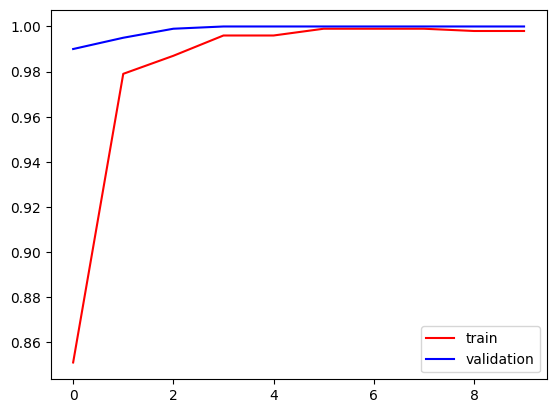

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

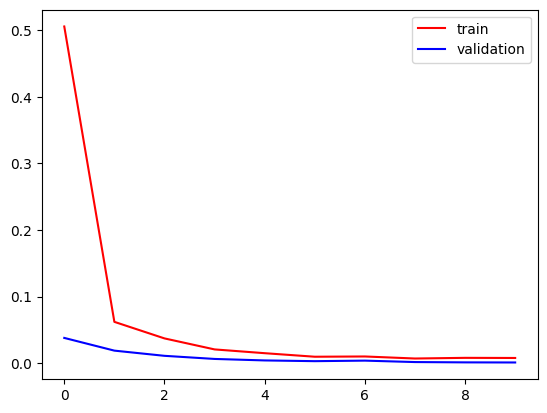

In [12]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()